## Task 5: Model Explainability with Grad-CAM

In this task, you will investigate whether a supervised classification model focuses on clinically relevant regions of the knee X-ray images when predicting the osteoarthritis class. To this end, you will use Gradient-weighted Class Activation Mapping (Grad-CAM), a visualization technique that highlights image regions that contribute most strongly to the model's prediction.

Interpretability is particularly important in medical imaging, where high classification performance alone is not sufficient. In addition to predicting the correct label, it is desirable that the model bases its decision on meaningful anatomical structures, such as the joint space, osteophyte regions, or other visible signs of severe osteoarthritis. Furthermore, interpretability can provide insight into why the model fails on specific cases.

Create a new notebook named `GradCAM.ipynb`. Use one of your previously trained supervised models from Task 2 or Task 3.

### 1. Select a trained classifier
- Choose your best performing model from one of the previous tasks.
- Clearly indicate which model you use for this analysis.
- Reload the trained model and verify that it produces the expected predictions on the test set.

### 2. Implement Grad-CAM
- Apply Grad-CAM to a suitable convolutional layer of the selected model.
- Generate Grad-CAM heatmaps for a number of test images.
- Overlay the heatmaps on the original X-ray images for visualization.

### 3. Qualitative analysis
- Visualize Grad-CAM results for at least a few correctly classified healthy images and a few correctly classified severe osteoarthritis images.
- Additionally, visualize Grad-CAM results for some misclassified examples.
- Compare whether the highlighted regions differ between healthy and severe cases.

### 4. Clinical interpretation
- Analyze whether the model appears to focus on clinically meaningful regions, such as the knee joint space.
- Discuss whether the highlighted regions are plausible from a medical imaging perspective.
- Investigate whether there are examples where the model seems to focus on irrelevant structures or image artifacts.

---

In your report, briefly discuss the following aspects:

- **Interpretability method:** Describe the Grad-CAM method and explain on which model and layer it was applied.
- **Qualitative findings:** Summarize the main observations from the Grad-CAM visualizations.
- **Clinical relevance:** Discuss whether the model focuses on anatomically and clinically plausible regions.
- **Limitations:** Reflect on the limitations of Grad-CAM as an interpretability tool and explain why such visualizations should be interpreted with caution.

# 1. Select a Trained Classifier — Baseline CNN

We use the best-performing baseline CNN from Task 2 (lr=0.001, dropout=0.5, trained on train+val, 30 epochs).

In [1]:
import sys

sys.path.insert(0, "../0_generalcode")
from gpu_helper import settest_torch_gpu

device = settest_torch_gpu()

PyTorch CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Keras backend: tensorflow
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Prediction shape: (5, 1)  — Keras is running on tensorflow , device: cuda


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import f1_score, accuracy_score
import os

In [3]:
from pipeline_helper import MyTransform

DATA_DIR = "../../data/1_source/"

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"), transform=MyTransform()
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {test_dataset.classes}")

Test samples: 146
Classes: ['0', '1']


In [4]:
class BaselineCNN(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.fc_block(x)
        return x

In [5]:
from model_helper import BaselineCNN

MODEL_PATH = "../2_basemodel/baseline_model.pth"
model = BaselineCNN.load(MODEL_PATH, device)
print("Model loaded successfully!")

Model loaded successfully!


In [6]:
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= 0.5).astype(int)

print(f"Test samples: {len(all_labels)}")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score: {f1_score(all_labels, all_preds):.4f}")

Test samples: 146
Accuracy: 0.9315
F1 Score: 0.9091


# 2. Implement Grad-CAM

Grad-CAM computes a heatmap by:
1. Performing a forward pass to obtain the model output.
2. Back-propagating the output score to a chosen convolutional layer.
3. Global-average-pooling the gradients over the spatial dimensions to get per-channel weights.
4. Taking the ReLU of the weighted sum of the feature maps — keeping only regions that positively contribute to the prediction.

We target **`conv_block[10]`** — the ReLU after the last Conv2d block — which produces 32x32 feature maps and is the deepest spatially-resolved activation before global pooling.

In [7]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self._hooks = [
            target_layer.register_forward_hook(self._save_activation),
            target_layer.register_full_backward_hook(self._save_gradient),
        ]

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, image_tensor):
        """image_tensor: (1, C, H, W) on device. Returns heatmap (H, W) normalized to [0, 1]."""
        self.model.eval()
        output = self.model(image_tensor).squeeze()
        self.model.zero_grad()
        output.backward()

        # Weight each feature map by the global-average-pooled gradient
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # (1, C, 1, 1)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, h, w)
        cam = (
            torch.relu(cam).squeeze().cpu().numpy()
        )  # keep only positive contributions

        if cam.max() > 0:
            cam = cam / cam.max()
        return cam

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()

In [8]:
# Display dataset: no normalization so images look natural when shown
display_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ]
)
display_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"), transform=display_transform
)

# Hook into conv_block[10]: last ReLU before MaxPool, output shape (1, 64, 32, 32)
grad_cam = GradCAM(model, model.gradcam_layer)
print("GradCAM target: conv_block[10] (last conv ReLU, feature map 32x32)")

GradCAM target: conv_block[10] (last conv ReLU, feature map 32x32)


In [9]:
from img_helper import overlay_heatmap, show_gradcam

# 3. Qualitative Analysis

In [10]:
correct_healthy = np.where((all_labels == 0) & (all_preds == 0))[0]
correct_oa = np.where((all_labels == 1) & (all_preds == 1))[0]
misclassified = np.where(all_labels != all_preds)[0]

print(f"Correctly classified healthy : {len(correct_healthy)}")
print(f"Correctly classified OA      : {len(correct_oa)}")
print(f"Misclassified                : {len(misclassified)}")

Correctly classified healthy : 86
Correctly classified OA      : 50
Misclassified                : 10


In [11]:
CLASS_NAMES = ["Healthy", "OA"]

c:\Users\Karel\.conda\envs\ai-course\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


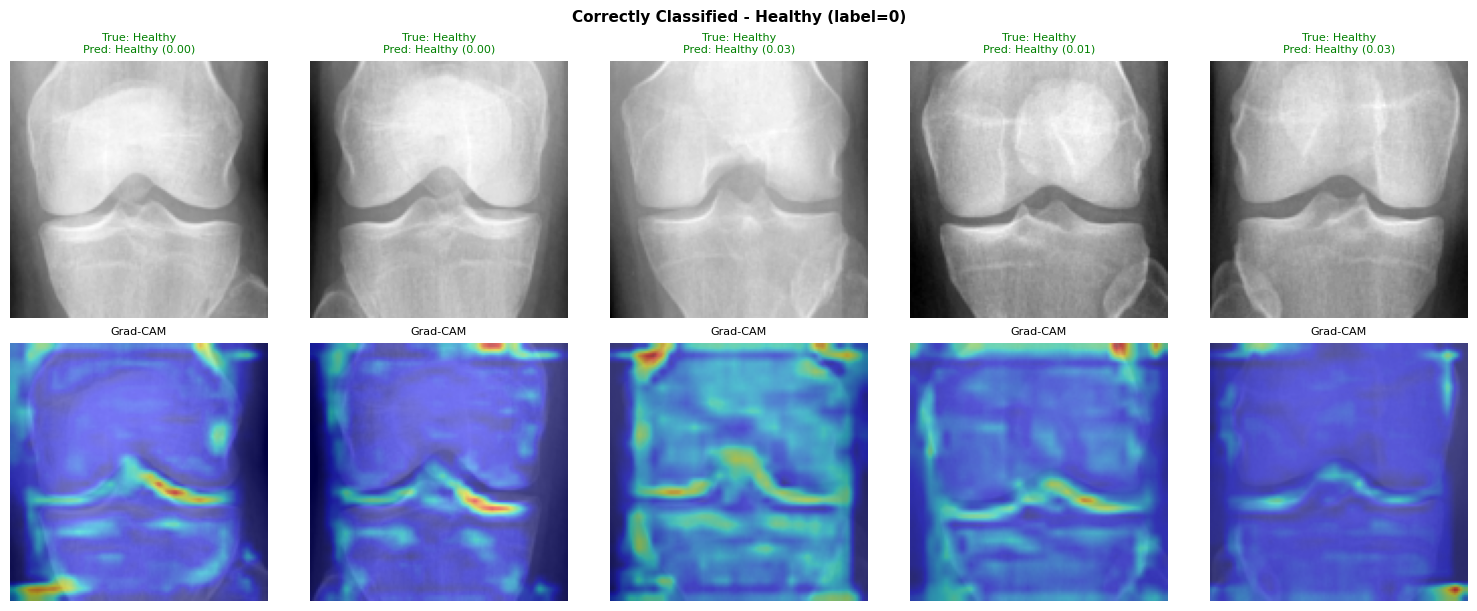

In [12]:
show_gradcam(
    correct_healthy,
    display_dataset,
    test_dataset,
    grad_cam,
    all_labels,
    all_preds,
    all_probs,
    CLASS_NAMES,
    device,
    title="Correctly Classified - Healthy (label=0)",
)

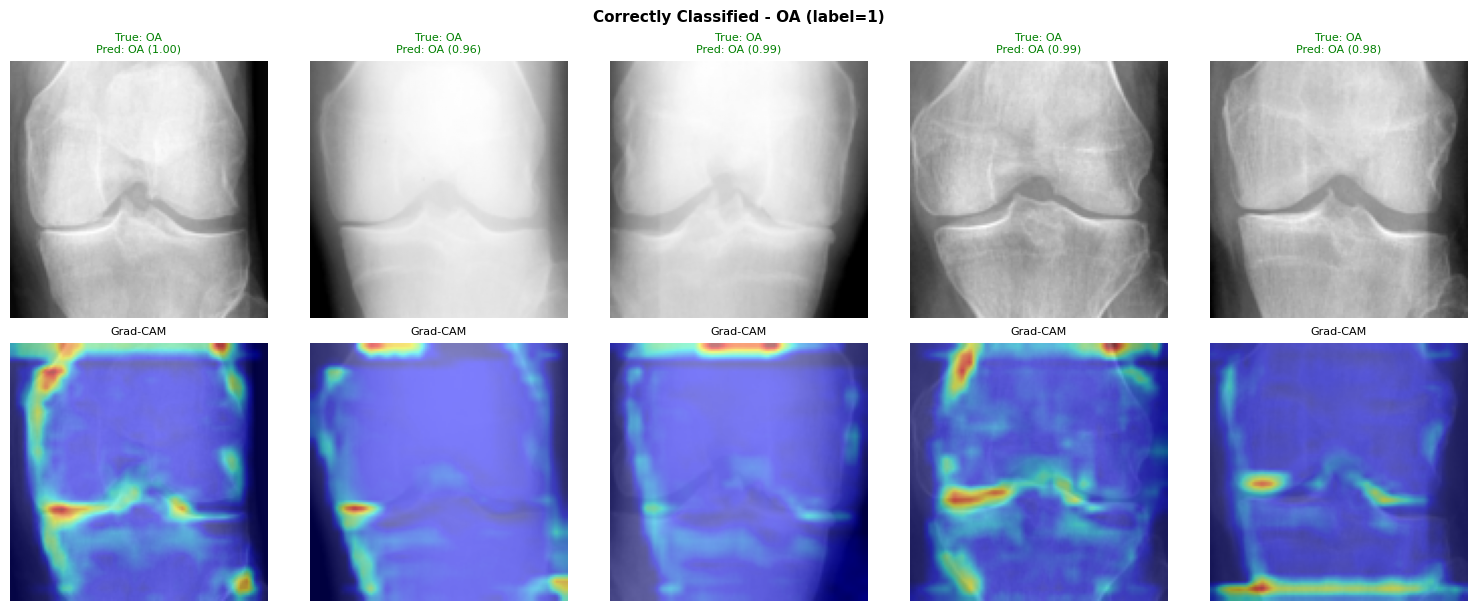

In [13]:
show_gradcam(
    correct_oa,
    display_dataset,
    test_dataset,
    grad_cam,
    all_labels,
    all_preds,
    all_probs,
    CLASS_NAMES,
    device,
    title="Correctly Classified - OA (label=1)",
)

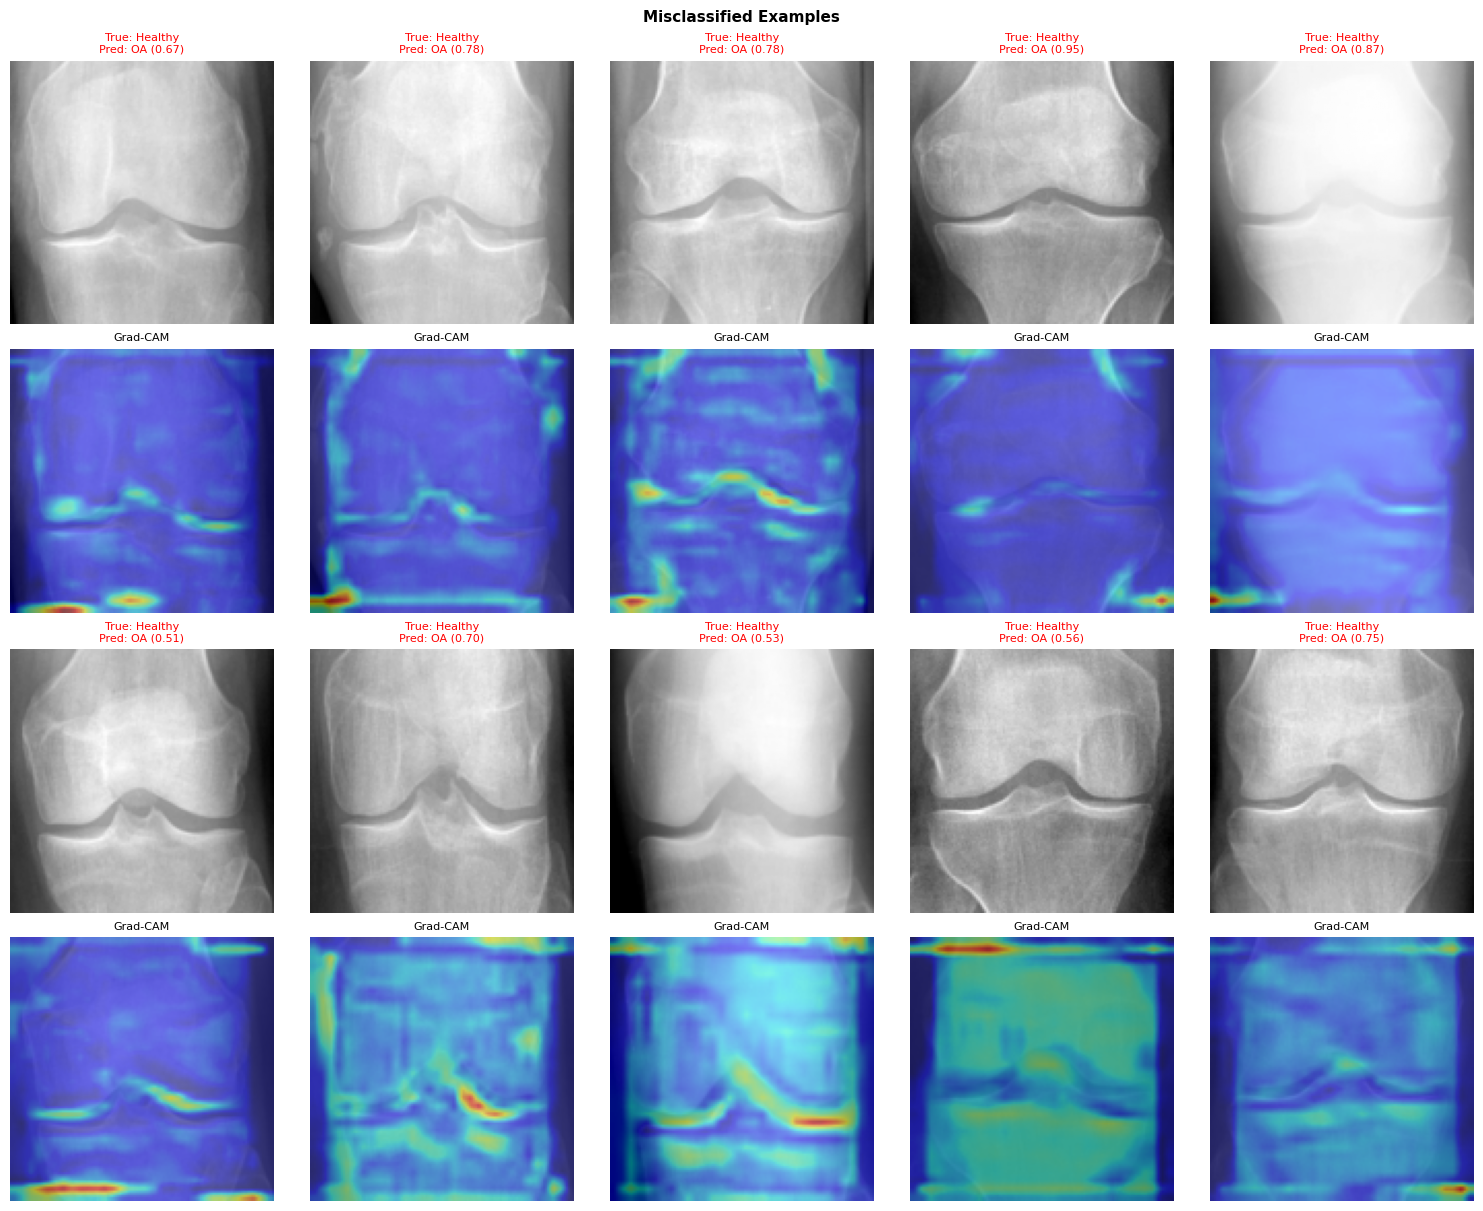

In [14]:
show_gradcam(
    misclassified,
    display_dataset,
    test_dataset,
    grad_cam,
    all_labels,
    all_preds,
    all_probs,
    CLASS_NAMES,
    device,
    title="Misclassified Examples",
    n=50,
)

# 4. Clinical Interpretation

In knee OA X-rays the clinically relevant region is the **knee joint space** — 
the gap between femur and tibia visible in the vertical centre of the image.
We quantify whether Grad-CAM activations are concentrated there (middle third, rows 43-85 of 128) 
or scattered over peripheral / irrelevant structures.

For each test image we compute two statistics:
- **Central-band fraction**: share of total Grad-CAM energy that falls inside the middle vertical third.
- **Vertical centre of mass (CoM)**: activation-weighted mean row, normalised to [0, 1] (0 = top, 1 = bottom).

A well-calibrated model should show high central-band fractions and CoM near 0.5 for **both** classes, 
because the joint space is the diagnostically relevant region regardless of label.

In [15]:
# Run GradCAM on every test image and collect spatial statistics
cam_stats = []

for idx in range(len(test_dataset)):
    img_tensor, _ = test_dataset[idx]
    img_input = img_tensor.unsqueeze(0).to(device)
    cam = grad_cam.generate(img_input)

    # Upsample to input resolution
    cam_t = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
    cam_up = F.interpolate(cam_t, size=(128, 128), mode="bilinear", align_corners=False)
    cam_up = cam_up.squeeze().numpy()

    H, W = cam_up.shape
    total = cam_up.sum() + 1e-8

    # Fraction of activation inside the central vertical third
    r1, r2 = H // 3, 2 * H // 3
    center_frac = cam_up[r1:r2, :].sum() / total

    # Vertical centre of mass (0 = top, 1 = bottom)
    y_idx = np.arange(H).reshape(-1, 1) / (H - 1)
    com_y = (cam_up * y_idx).sum() / total

    cam_stats.append(
        {
            "idx": idx,
            "center_frac": float(center_frac),
            "com_y": float(com_y),
            "label": int(all_labels[idx]),
            "pred": int(all_preds[idx]),
        }
    )

center_frac_arr = np.array([s["center_frac"] for s in cam_stats])
com_y_arr = np.array([s["com_y"] for s in cam_stats])
healthy_mask = all_labels == 0
oa_mask = all_labels == 1

print(
    f"Mean central-band fraction  — Healthy: {center_frac_arr[healthy_mask].mean():.3f},  OA: {center_frac_arr[oa_mask].mean():.3f}"
)
print(
    f"Mean vertical CoM (0.5=mid) — Healthy: {com_y_arr[healthy_mask].mean():.3f},  OA: {com_y_arr[oa_mask].mean():.3f}"
)

Mean central-band fraction  — Healthy: 0.321,  OA: 0.349
Mean vertical CoM (0.5=mid) — Healthy: 0.513,  OA: 0.516


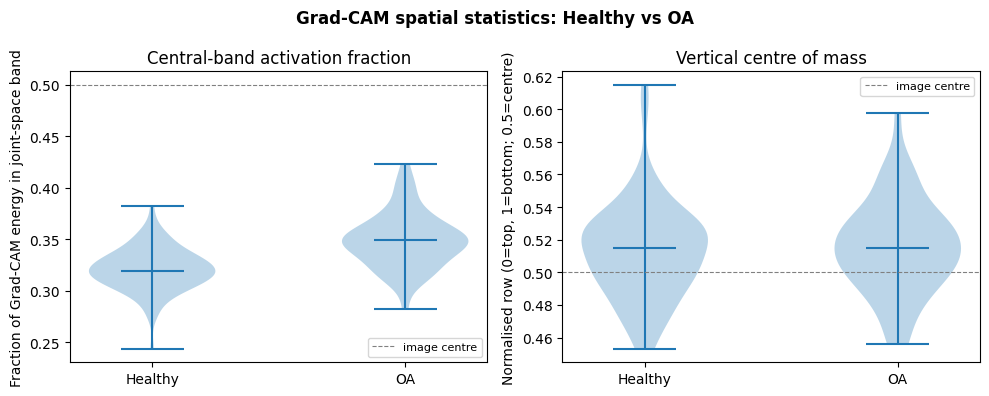

In [16]:
# Compare activation distributions: Healthy vs OA
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

datasets_info = [
    (
        center_frac_arr,
        "Central-band activation fraction",
        "Fraction of Grad-CAM energy in joint-space band",
    ),
    (
        com_y_arr,
        "Vertical centre of mass",
        "Normalised row (0=top, 1=bottom; 0.5=centre)",
    ),
]

for ax, (values, title, ylabel) in zip(axes, datasets_info):
    data = [values[healthy_mask], values[oa_mask]]
    parts = ax.violinplot(data, positions=[0, 1], showmedians=True)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Healthy", "OA"])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="image centre")
    ax.legend(fontsize=8)

plt.suptitle("Grad-CAM spatial statistics: Healthy vs OA", fontweight="bold")
plt.tight_layout()
plt.show()

Central-band fractions for lowest-focus images: [0.243 0.273 0.277 0.282 0.282 0.289]


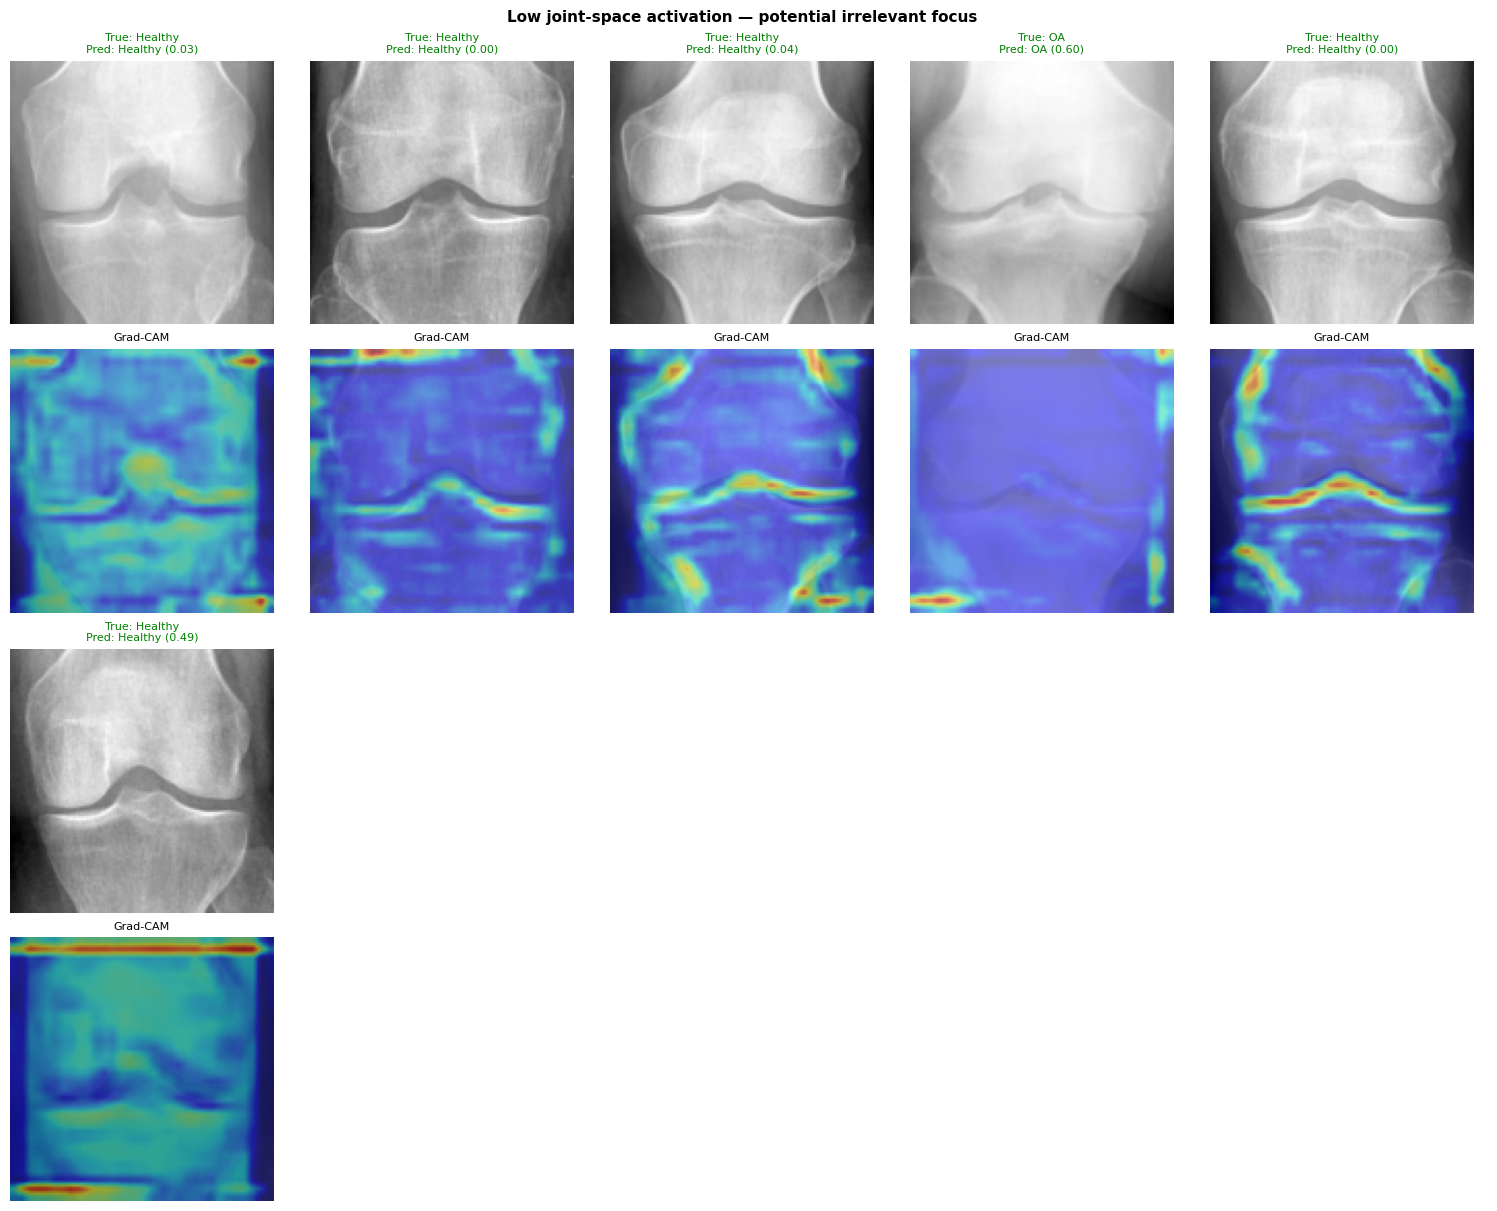

In [17]:
# Images where the model focuses LEAST on the joint space (possible irrelevant structures)
low_center_idx = np.argsort(center_frac_arr)[:6]
print(
    "Central-band fractions for lowest-focus images:",
    center_frac_arr[low_center_idx].round(3),
)
show_gradcam(
    low_center_idx,
    display_dataset,
    test_dataset,
    grad_cam,
    all_labels,
    all_preds,
    all_probs,
    CLASS_NAMES,
    device,
    title="Low joint-space activation — potential irrelevant focus",
    n=6,
)